### visualisasi sistem persamaan linier 

Titik potong (solusi) ditemukan di: x = 5, y = 5


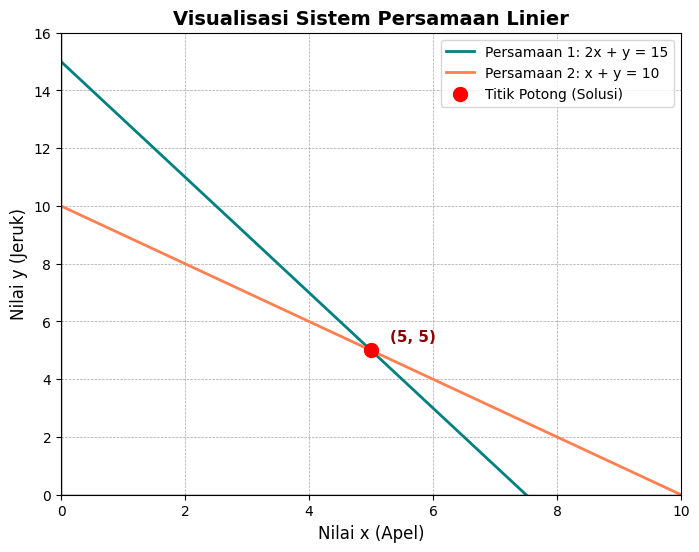

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Mendefinisikan Sistem Persamaan Linier dalam bentuk Matriks
# Persamaan 1: 2x + 1y = 15
# Persamaan 2: 1x + 1y = 10
# Format: A * [x, y] = B
A = np.array([
    [2, 1], 
    [1, 1]
])
B = np.array([15, 10])

# Menyelesaikan SPL menggunakan operasi aljabar linear bawaan NumPy
solusi = np.linalg.solve(A, B)
x_potong, y_potong = solusi

print(f"Titik potong (solusi) ditemukan di: x = {x_potong:.0f}, y = {y_potong:.0f}")

# 2. Menyiapkan data untuk visualisasi (rentang nilai x dari 0 hingga 10)
x = np.linspace(0, 10, 100)

# Mengubah persamaan menjadi format y = ... agar bisa digambar
# Persamaan 1 (2x + y = 15) -> y = 15 - 2x
y1 = 15 - 2 * x

# Persamaan 2 (x + y = 10) -> y = 10 - x
y2 = 10 - x

# 3. Menggambar Grafik menggunakan Matplotlib
plt.figure(figsize=(8, 6))

# Menggambar kedua garis
plt.plot(x, y1, label='Persamaan 1: 2x + y = 15', color='teal', linewidth=2)
plt.plot(x, y2, label='Persamaan 2: x + y = 10', color='coral', linewidth=2)

# Menandai titik potong (solusi)
plt.scatter(x_potong, y_potong, color='red', s=100, zorder=5, label='Titik Potong (Solusi)')
plt.text(x_potong + 0.3, y_potong + 0.3, f'({x_potong:.0f}, {y_potong:.0f})', fontsize=11, fontweight='bold', color='darkred')

# Mengatur tampilan tata letak (grid, label, judul)
plt.title('Visualisasi Sistem Persamaan Linier', fontsize=14, fontweight='bold')
plt.xlabel('Nilai x (Apel)', fontsize=12)
plt.ylabel('Nilai y (Jeruk)', fontsize=12)

# Menetapkan batas tampilan sumbu x dan y
plt.xlim(0, 10)
plt.ylim(0, 16)

# Menambahkan garis bantu (grid) dan garis nol
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Menampilkan legenda
plt.legend()

# Menampilkan hasil visualisasi
plt.show()

### visualisasi sistem persamaan non linier

In [ ]:
"""
SPL Non-Linier Interaktif
=========================
Sistem 2 persamaan non-linier dengan slider parameter.
Titik potong dihitung otomatis menggunakan scipy (fsolve) jika tersedia, atau fallback ke bisection.

Jalankan sebagai script:
    python spl_nonlinier.py

ATAU di Jupyter tambahkan di cell pertama:
    %matplotlib widget
    (pip install ipympl jika belum)
"""
# ── Deteksi Lingkungan & Set Matplotlib Backend ──────────────────
import sys
import os

is_build = (
    os.environ.get('JUPYTER_BOOK_BUILD') or 
    'sphinx' in sys.modules or 
    any('hist_file=:memory:' in arg for arg in sys.argv)
)

try:
    from IPython import get_ipython
    ipy = get_ipython()
    if ipy is not None:
        if not is_build:
            ipy.run_line_magic('matplotlib', 'widget')
        else:
            ipy.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import Slider, RadioButtons

# Fallback untuk scipy.optimize.brentq
try:
    from scipy.optimize import brentq
except ImportError:
    def brentq(f, a, b, xtol=1e-6, *args, **kwargs):
        fa = f(a)
        fb = f(b)
        if fa * fb > 0:
            raise ValueError("Root is not bracketed")
        for _ in range(100):
            c = 0.5 * (a + b)
            fc = f(c)
            if abs(fc) < xtol or (b - a) < xtol:
                return c
            if fa * fc < 0:
                b = c
                fb = fc
            else:
                a = c
                fa = fc
        return 0.5 * (a + b)

# ── Range sumbu ──────────────────────────────────────────────────
x = np.linspace(-10, 10, 800)

# ================================================================
# DEFINISI PASANGAN PERSAMAAN NON-LINIER
# ================================================================
PASANGAN = {
    'Kuadrat vs Linier\ny=ax²+b  |  y=cx+d': {
        'f1': lambda x, p: p[0]*x**2 + p[1],
        'f2': lambda x, p: p[2]*x + p[3],
        'label1': r'$y = ax^2 + b$',
        'label2': r'$y = cx + d$',
        'params': ['a','b','c','d'],
        'init':   [1.0, -3.0, 2.0, 1.0],
        'range':  [(-5,5),(-10,10),(-5,5),(-10,10)],
        'colors': ['#3b82f6', '#3b82f6', '#ef4444', '#ef4444'],
    },
    'Lingkaran vs Linier\nx²+y²=r²  |  y=cx+d': {
        # f1: y positif lingkaran, f2: y negatif (kurva bawah)
        'f1': lambda x, p: np.where(p[0]**2 - x**2 >= 0,
                                     np.sqrt(np.maximum(p[0]**2 - x**2, 0)), np.nan),
        'f1b': lambda x, p: np.where(p[0]**2 - x**2 >= 0,
                                      -np.sqrt(np.maximum(p[0]**2 - x**2, 0)), np.nan),
        'f2': lambda x, p: p[1]*x + p[2],
        'label1': r'$x^2 + y^2 = r^2$',
        'label2': r'$y = cx + d$',
        'params': ['r','c','d'],
        'init':   [4.0, 1.0, 0.0],
        'range':  [(1,8),(-5,5),(-10,10)],
        'lingkaran': True,
        'colors': ['#3b82f6', '#ef4444', '#ef4444'],
    },
    'Sinus vs Kuadrat\ny=a·sin(bx)  |  y=cx²+d': {
        'f1': lambda x, p: p[0]*np.sin(p[1]*x),
        'f2': lambda x, p: p[2]*x**2 + p[3],
        'label1': r'$y = a\sin(bx)$',
        'label2': r'$y = cx^2 + d$',
        'params': ['a','b','c','d'],
        'init':   [3.0, 1.0, 0.1, -2.0],
        'range':  [(-5,5),(-3,3),(-2,2),(-5,5)],
        'colors': ['#3b82f6', '#3b82f6', '#ef4444', '#ef4444'],
    },
    'Eksponensial vs Kuadrat\ny=a·eˣ+b  |  y=cx²+d': {
        'f1': lambda x, p: p[0]*np.exp(np.clip(x, -10, 3)) + p[1],
        'f2': lambda x, p: p[2]*x**2 + p[3],
        'label1': r'$y = ae^x + b$',
        'label2': r'$y = cx^2 + d$',
        'params': ['a','b','c','d'],
        'init':   [0.5, -5.0, 0.5, 0.0],
        'range':  [(-3,3),(-10,10),(-3,3),(-10,10)],
        'colors': ['#3b82f6', '#3b82f6', '#ef4444', '#ef4444'],
    },
}

# ================================================================
# CARI TITIK POTONG
# ================================================================
def cari_titik_potong(f1, f2, params, nama):
    titik = []
    
    # 1. Kuadrat vs Linier (Analytical Solver)
    if 'Kuadrat vs Linier' in nama:
        # y = a*x^2 + b
        # y = c*x + d
        # a*x^2 - c*x + (b - d) = 0
        a, b, c, d = params
        if abs(a) < 1e-9:
            # Linear: -c*x + (b - d) = 0 => c*x = b - d
            if abs(c) > 1e-9:
                xr = (b - d) / c
                if -10 <= xr <= 10:
                    yr = c * xr + d
                    titik.append((round(xr, 3), round(yr, 3)))
        else:
            A = a
            B = -c
            C = b - d
            D = B**2 - 4*A*C
            if D >= -1e-9:
                D = max(0.0, D)
                for sign in ([1, -1] if D > 0 else [0]):
                    xr = (-B + sign * np.sqrt(D)) / (2 * A)
                    if -10 <= xr <= 10:
                        yr = c * xr + d
                        if not any(abs(xr - tp[0]) < 0.05 for tp in titik):
                            titik.append((round(xr, 3), round(yr, 3)))
        return titik

    # 2. Lingkaran vs Linier (Analytical Solver)
    elif 'Lingkaran vs Linier' in nama:
        # x^2 + y^2 = r^2
        # y = c*x + d
        # (1 + c^2)*x^2 + 2*c*d*x + (d^2 - r^2) = 0
        r, c, d = params
        A = 1 + c**2
        B = 2 * c * d
        C = d**2 - r**2
        D = B**2 - 4*A*C
        if D >= -1e-9:
            D = max(0.0, D)
            for sign in ([1, -1] if D > 0 else [0]):
                xr = (-B + sign * np.sqrt(D)) / (2 * A)
                if -10 <= xr <= 10 and abs(xr) <= r:
                    yr = c * xr + d
                    if not any(abs(xr - tp[0]) < 0.05 for tp in titik):
                        titik.append((round(xr, 3), round(yr, 3)))
        return titik

    # 3. Sinus vs Kuadrat & Eksponensial vs Kuadrat (Numerical Root Finding)
    else:
        xx = np.linspace(-9.9, 9.9, 2000)
        try:
            y1 = f1(xx, params)
            y2 = f2(xx, params)
            diff = y1 - y2
            valid = ~(np.isnan(diff) | np.isinf(diff))
            xv = xx[valid]
            dv = diff[valid]

            for i in range(len(xv) - 1):
                if dv[i] * dv[i+1] < 0:
                    try:
                        def eq(xval):
                            return f1(np.array([xval]), params)[0] - f2(np.array([xval]), params)[0]
                        xr = brentq(eq, xv[i], xv[i+1], xtol=1e-6)
                        yr = float(f1(np.array([xr]), params)[0])
                        if not any(abs(xr - tp[0]) < 0.05 for tp in titik):
                            titik.append((round(xr, 3), round(yr, 3)))
                    except:
                        pass
        except:
            pass
        return titik

# ================================================================
# SETUP FIGURE
# ================================================================
fig = plt.figure(figsize=(12, 8))
fig.patch.set_facecolor('#f8fafc')

# Area grafik
ax = fig.add_axes([0.30, 0.38, 0.67, 0.55])
ax.set_facecolor('#ffffff')
ax.set_xlim(-10, 10)
ax.set_ylim(-15, 15)
ax.grid(True, linestyle='--', alpha=0.5, color='#cbd5e1')
ax.axhline(0, color='#1e293b', linewidth=1.2)
ax.axvline(0, color='#1e293b', linewidth=1.2)
ax.tick_params(labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor('#94a3b8')

title_txt = ax.set_title('', fontsize=12, fontweight='bold', color='#1e293b', pad=10)

# Lines
line1,     = ax.plot([], [], lw=2.5, color='#3b82f6', label='Persamaan 1', zorder=4)
line1b,    = ax.plot([], [], lw=2.5, color='#3b82f6', linestyle='--', zorder=4)  # lingkaran bawah
line2,     = ax.plot([], [], lw=2.5, color='#ef4444', label='Persamaan 2', zorder=4)
scatter_tp = ax.scatter([], [], s=120, color='#f59e0b', edgecolors='#92400e',
                        zorder=6, label='Titik Potong')
annot_list = []  # label titik potong dinamis

ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

# Info box titik potong
info_box = ax.text(
    -9.5, 13.5, '', fontsize=8.5, color='#1e293b',
    fontfamily='monospace', va='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fefce8',
              edgecolor='#fbbf24', alpha=0.95)
)

# ================================================================
# RADIO BUTTONS — pilih jenis persamaan
# ================================================================
ax_radio = fig.add_axes([0.01, 0.50, 0.27, 0.42], facecolor='#f1f5f9')
ax_radio.set_title('Jenis Persamaan', fontsize=9, fontweight='bold', pad=6)
radio = RadioButtons(
    ax_radio,
    list(PASANGAN.keys()),
    activecolor='#3b82f6'
)
for label in radio.labels:
    label.set_fontsize(8)

# ================================================================
# SLIDERS — 4 parameter (a, b, c, d)
# ================================================================
axcolor = '#f1f5f9'
slider_axes = [
    fig.add_axes([0.30, 0.27, 0.60, 0.025], facecolor=axcolor),
    fig.add_axes([0.30, 0.22, 0.60, 0.025], facecolor=axcolor),
    fig.add_axes([0.30, 0.17, 0.60, 0.025], facecolor=axcolor),
    fig.add_axes([0.30, 0.12, 0.60, 0.025], facecolor=axcolor),
]
sliders = [None, None, None, None]

# Label keterangan slider
info_slider = fig.text(0.30, 0.07, '', fontsize=8.5, color='#475569',
                       fontfamily='monospace')

# ================================================================
# FUNGSI UPDATE
# ================================================================
def update(val=None):
    nama = radio.value_selected
    cfg  = PASANGAN[nama]

    params_nama = cfg['params']
    is_lingkaran = cfg.get('lingkaran', False)

    # Ambil nilai slider sesuai jumlah param
    n = len(params_nama)
    params_val = []
    for i in range(n):
        if sliders[i] is not None:
            params_val.append(sliders[i].val)
        else:
            params_val.append(cfg['init'][i])

    # Update label slider
    info_txt = '  '.join(
        f'{params_nama[i]} = {params_val[i]:.2f}' for i in range(n)
    )
    info_slider.set_text('Parameter aktif: ' + info_txt)

    # Hitung y
    f1 = cfg['f1']
    f2 = cfg['f2']

    y1 = f1(x, params_val)
    y2 = f2(x, params_val)

    line1.set_data(x, y1)
    line1.set_label(cfg['label1'])
    line2.set_data(x, y2)
    line2.set_label(cfg['label2'])

    # Lingkaran: gambar busur bawah juga
    if is_lingkaran and 'f1b' in cfg:
        y1b = cfg['f1b'](x, params_val)
        line1b.set_data(x, y1b)
        line1b.set_visible(True)
    else:
        line1b.set_visible(False)

    # Titik potong
    titik = cari_titik_potong(f1, f2, params_val, nama)

    # Hapus anotasi lama
    for ann in annot_list:
        ann.remove()
    annot_list.clear()

    if titik:
        xs_tp = [t[0] for t in titik]
        ys_tp = [t[1] for t in titik]
        scatter_tp.set_offsets(np.column_stack([xs_tp, ys_tp]))

        info_lines = [f'✔ {len(titik)} titik potong ditemukan:']
        for i, (xp, yp) in enumerate(titik):
            info_lines.append(f'  P{i+1} = ({xp:.3f}, {yp:.3f})')
            ann = ax.annotate(
                f'P{i+1}({xp:.2f}, {yp:.2f})',
                xy=(xp, yp),
                xytext=(xp + 0.4, yp + 0.8),
                fontsize=7.5, color='#92400e', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#92400e', lw=1),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#fef9c3',
                          edgecolor='#fbbf24', alpha=0.9),
                zorder=7
            )
            annot_list.append(ann)
        info_box.set_text('\n'.join(info_lines))
    else:
        scatter_tp.set_offsets(np.empty((0, 2)))
        info_box.set_text('✘ Tidak ada titik potong\n  di domain [-10, 10]')

    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
    title_txt.set_text(f'SPL Non-Linier: {nama.split(chr(10))[0]}')
    fig.canvas.draw_idle()


def on_radio(label):
    cfg = PASANGAN[label]
    params_nama = cfg['params']
    params_init = cfg['init']
    params_range = cfg['range']
    colors = cfg.get('colors', ['#3b82f6', '#3b82f6', '#ef4444', '#ef4444'])
    n = len(params_nama)
    
    # Recreate the active sliders
    for i in range(4):
        slider_axes[i].clear()
        if i < n:
            lo, hi = params_range[i]
            slider_axes[i].set_visible(True)
            sliders[i] = Slider(
                slider_axes[i], 
                f'param {params_nama[i]}', 
                lo, hi, 
                valinit=params_init[i], 
                color=colors[i]
            )
            sliders[i].on_changed(update)
        else:
            slider_axes[i].set_visible(False)
            sliders[i] = None
            
    update()

# ── Daftarkan event ──────────────────────────────────────────────
radio.on_clicked(on_radio)

# Inisialisasi tampilan awal
on_radio(list(PASANGAN.keys())[0])

# ── Catatan di bawah ─────────────────────────────────────────────
fig.text(0.30, 0.02,
         '📌 Titik potong dihitung secara analitik & numerik  |  '
         'Geser slider untuk ubah parameter  |  Klik radio untuk ganti fungsi',
         fontsize=8, color='#64748b', ha='left')

plt.suptitle('Eksplorasi Sistem Persamaan Non-Linier',
             fontsize=14, fontweight='bold', color='#0f172a', y=0.98)

plt.show()

ModuleNotFoundError: No module named 'scipy'

### geogebra visualisation linier

<iframe src="https://www.geogebra.org/calculator/gz9xyxsf?embed" width="800" height="600" allowfullscreen style="border: 1px solid #e4e4e4;border-radius: 4px;" frameborder="0"></iframe>


### geogebra visualisation non linier 

<iframe src="https://www.geogebra.org/calculator/gz9xyxsf?embed" width="800" height="600" allowfullscreen style="border: 1px solid #e4e4e4;border-radius: 4px;" frameborder="0"></iframe>
